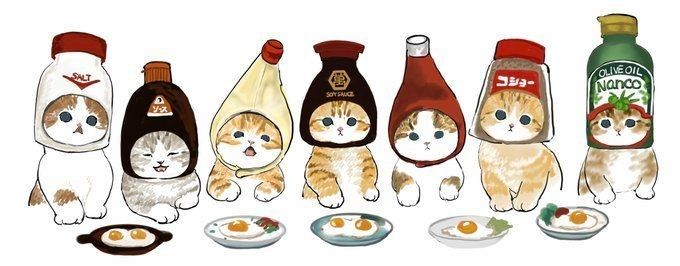

# Importando Bibliotecas

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

# Dados

In [2]:
df = pd.read_csv('kyphosis.csv')

In [3]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Kyphosis  81 non-null     str  
 1   Age       81 non-null     int64
 2   Number    81 non-null     int64
 3   Start     81 non-null     int64
dtypes: int64(3), str(1)
memory usage: 3.2 KB


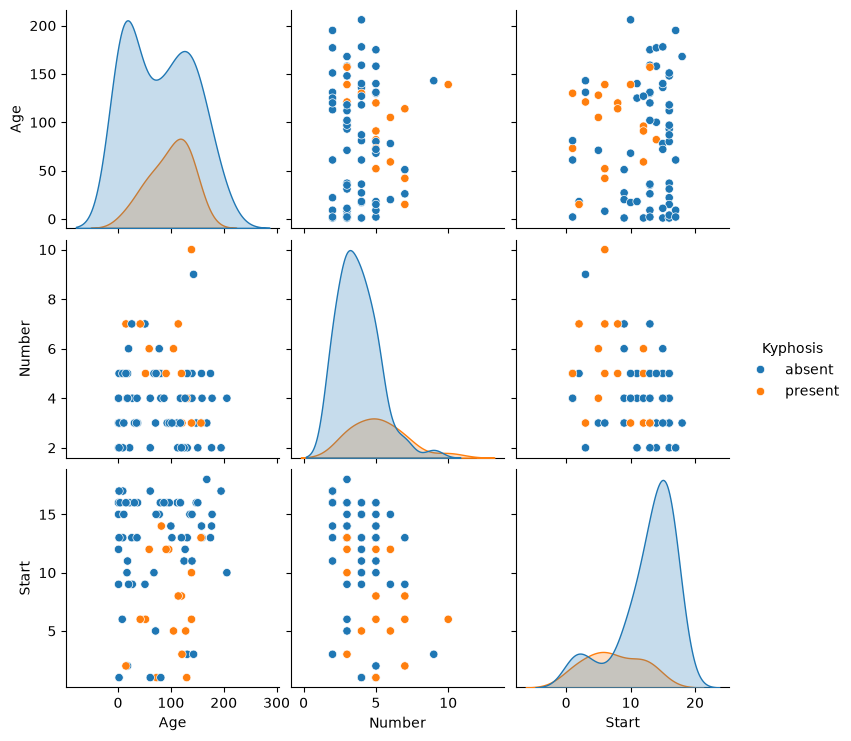

In [5]:
sns.pairplot(df, hue='Kyphosis')

# Train Test Split

In [6]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop('Kyphosis', axis=1)

In [9]:
y = df['Kyphosis']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Árvore de Decisão

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
dtree = DecisionTreeClassifier()

In [13]:
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
predictions = dtree.predict(X_test)

# Predição e Avaliação

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
print(confusion_matrix(y_test, predictions))
print('\n')
print(classification_report(y_test, predictions))

[[17  3]
 [ 2  3]]


              precision    recall  f1-score   support

      absent       0.89      0.85      0.87        20
     present       0.50      0.60      0.55         5

    accuracy                           0.80        25
   macro avg       0.70      0.72      0.71        25
weighted avg       0.82      0.80      0.81        25



# Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
rfc = RandomForestClassifier(n_estimators=200)

In [22]:
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
rfc.pred = rfc.predict(X_test)

In [24]:
print(confusion_matrix(y_test, rfc.pred))
print('\n')
print(classification_report(y_test, rfc.pred))

[[18  2]
 [ 3  2]]


              precision    recall  f1-score   support

      absent       0.86      0.90      0.88        20
     present       0.50      0.40      0.44         5

    accuracy                           0.80        25
   macro avg       0.68      0.65      0.66        25
weighted avg       0.79      0.80      0.79        25



# Visualização da Árvore

In [28]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

features = list(df.columns[1:])
features

['Age', 'Number', 'Start']

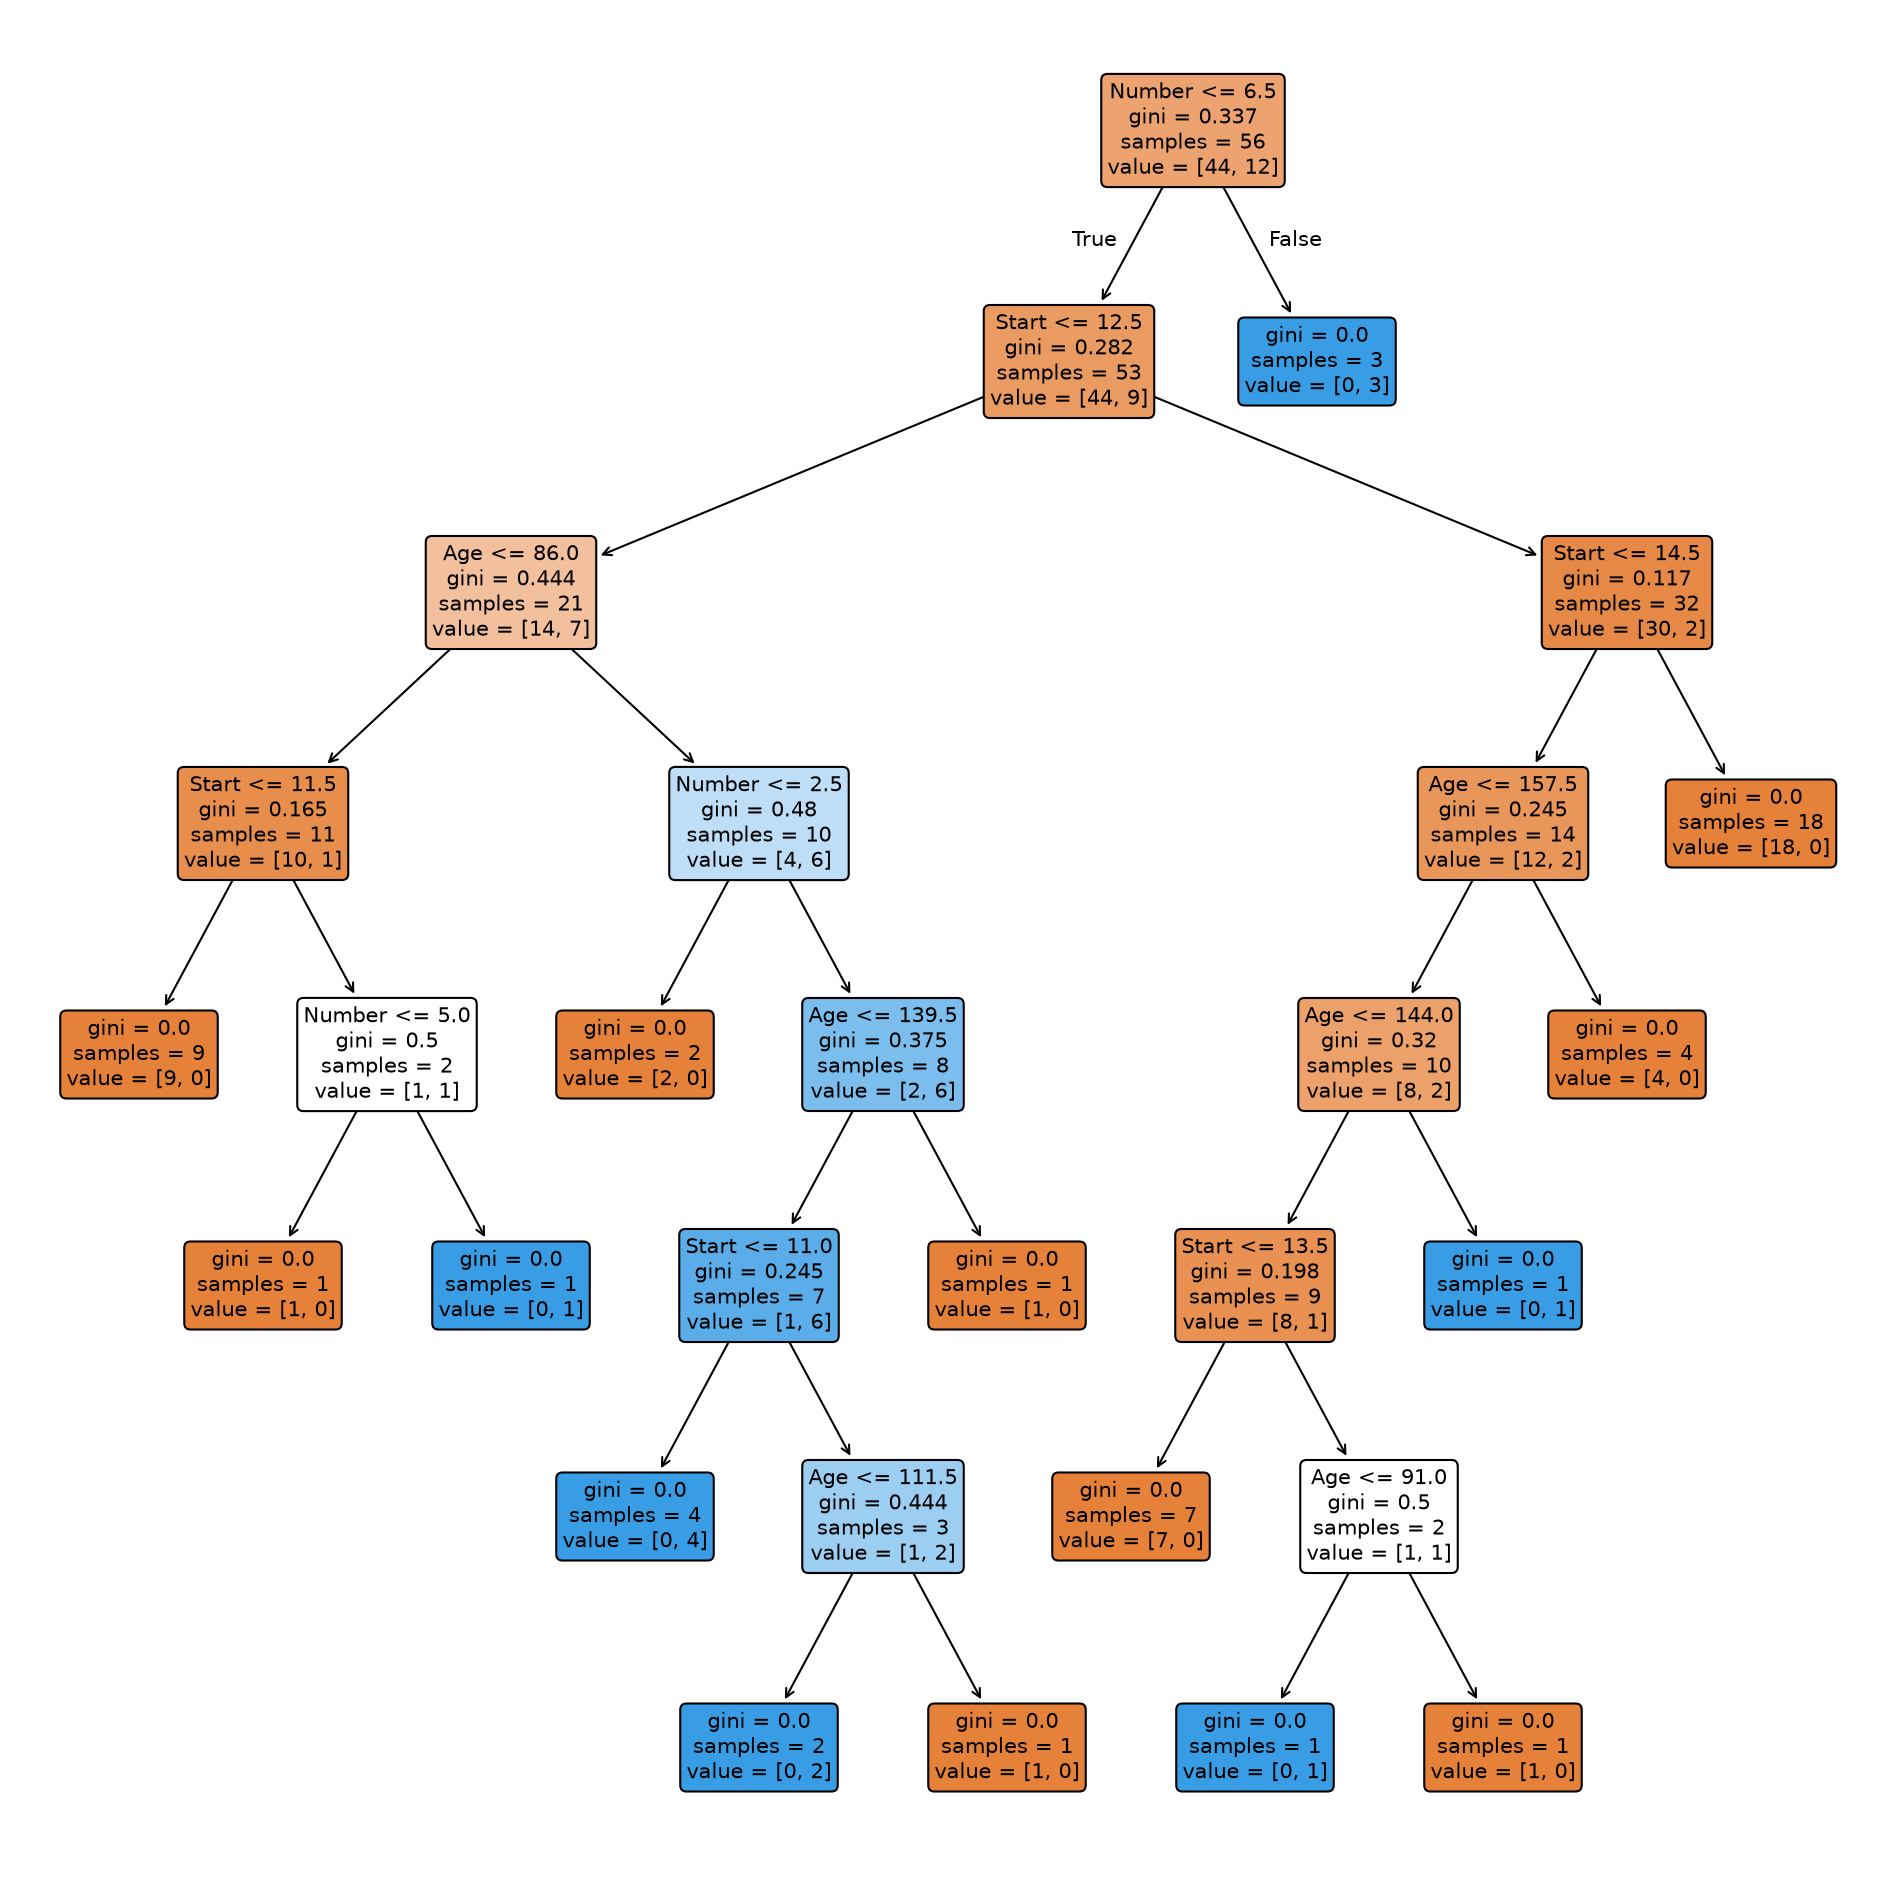

In [34]:
from sklearn.tree import plot_tree

# O figsize (largura, altura) invertido força uma visualização vertical
plt.figure(figsize=(16, 16), dpi=150) 
plot_tree(dtree, feature_names=features, filled=True, rounded=True, fontsize=10)
plt.show()

---
# Correção do Codigo
---

## Importando bibliotecas e carregando os dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv('kyphosis.csv')
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


## Exploração inicial dos dados

In [2]:
print("Formato (linhas, colunas):", df.shape)

print("\n--- Info ---")
df.info()

print("\n--- Valores ausentes por coluna ---")
print(df.isnull().sum().to_string())

print("\n--- Balanceamento da classe alvo ---")
print(df['Kyphosis'].value_counts())
print(df['Kyphosis'].value_counts(normalize=True).round(3))

print("\n--- Estatísticas descritivas ---")
df.describe().round(2)

Formato (linhas, colunas): (81, 4)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Kyphosis  81 non-null     str  
 1   Age       81 non-null     int64
 2   Number    81 non-null     int64
 3   Start     81 non-null     int64
dtypes: int64(3), str(1)
memory usage: 3.2 KB

--- Valores ausentes por coluna ---
Kyphosis    0
Age         0
Number      0
Start       0

--- Balanceamento da classe alvo ---
Kyphosis
absent     64
present    17
Name: count, dtype: int64
Kyphosis
absent     0.79
present    0.21
Name: proportion, dtype: float64

--- Estatísticas descritivas ---


,Age,Number,Start
count,81.00,81.00,81.00
mean,83.65,4.05,11.49
std,58.10,1.62,4.88
min,1.00,2.00,1.00
25%,26.00,3.00,9.00
50%,87.00,4.00,13.00
75%,130.00,5.00,16.00
max,206.00,10.00,18.00


## Análise exploratória (pairplot)

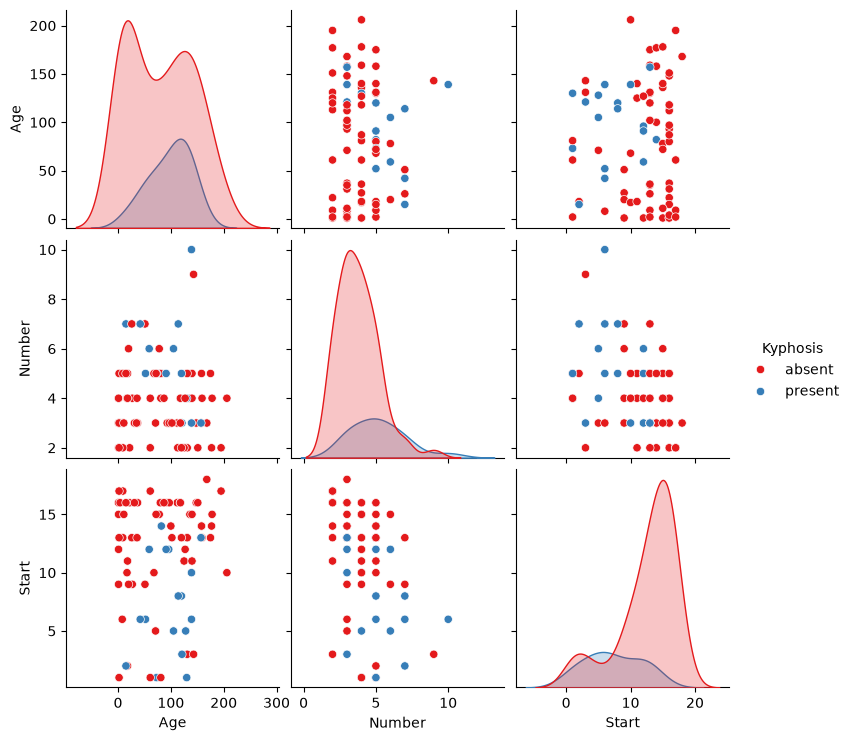

In [3]:
sns.pairplot(df, hue='Kyphosis', palette='Set1')
plt.show()

## Separando X e y e dividindo em treino e teste

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Kyphosis', axis=1)
y = df['Kyphosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=101,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

print("\nContagem no treino:")
print(y_train.value_counts().to_string())
print("\nContagem no teste:")
print(y_test.value_counts().to_string())

X_train: (56, 3)
X_test:  (25, 3)

Contagem no treino:
Kyphosis
absent     44
present    12

Contagem no teste:
Kyphosis
absent     20
present     5


## Árvore de decisão sem limites (baseline)

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

dtree = DecisionTreeClassifier(random_state=101)
dtree.fit(X_train, y_train)

pred_tree = dtree.predict(X_test)

print("--- Diagnóstico de overfitting ---")
print(f"Acurácia no treino: {dtree.score(X_train, y_train):.3f}")
print(f"Acurácia no teste:  {dtree.score(X_test, y_test):.3f}")
print(f"Profundidade da árvore: {dtree.get_depth()}")
print(f"Número de folhas:       {dtree.get_n_leaves()}")

print("\n--- Patamar: sempre prever 'absent' ---")
print(f"Acurácia: {(y_test == 'absent').mean():.3f}")

print("\nMatriz de confusão (linhas = real, colunas = previsto; ordem: absent, present):")
print(confusion_matrix(y_test, pred_tree))

print("\nClassification report:")
print(classification_report(y_test, pred_tree))

--- Diagnóstico de overfitting ---
Acurácia no treino: 1.000
Acurácia no teste:  0.800
Profundidade da árvore: 7
Número de folhas:       14

--- Patamar: sempre prever 'absent' ---
Acurácia: 0.800

Matriz de confusão (linhas = real, colunas = previsto; ordem: absent, present):
[[17  3]
 [ 2  3]]

Classification report:
              precision    recall  f1-score   support

      absent       0.89      0.85      0.87        20
     present       0.50      0.60      0.55         5

    accuracy                           0.80        25
   macro avg       0.70      0.72      0.71        25
weighted avg       0.82      0.80      0.81        25



## Visualizando a árvore

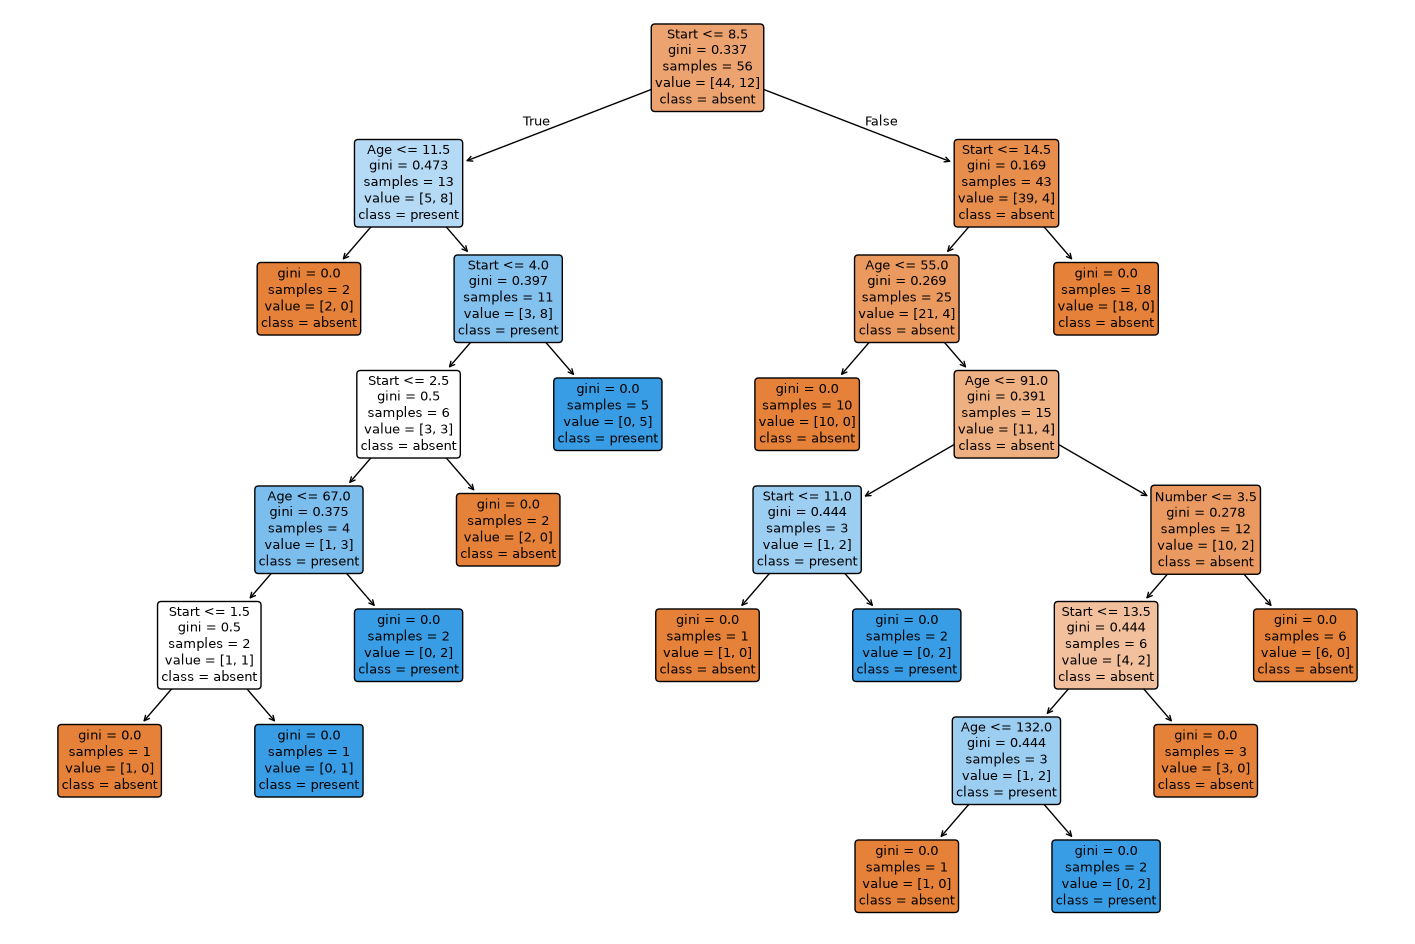

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 12))
plot_tree(
    dtree,
    feature_names=X_train.columns,
    class_names=dtree.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

## Árvore com poda (escolhida por validação cruzada)

In [8]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=101)

param_grid = {
    'max_depth': [1, 2, 3, 4, 5, None],
    'min_samples_leaf': [1, 2, 3, 5, 8, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=101),
    param_grid,
    cv=cv,
    scoring='balanced_accuracy'
)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print(f"Melhor balanced_accuracy (CV): {grid.best_score_:.3f}")

# referência: árvore sem limites, avaliada do mesmo jeito
base_cv = cross_val_score(
    DecisionTreeClassifier(random_state=101),
    X_train, y_train, cv=cv, scoring='balanced_accuracy'
)
print(f"Árvore sem limites (CV):       {base_cv.mean():.3f}")

# os 8 melhores
resultado = pd.DataFrame(grid.cv_results_)[
    ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False)
print("\nTop 8 combinações:")
print(resultado.head(8).round(3).to_string(index=False))

Melhores parâmetros: {'max_depth': 1, 'min_samples_leaf': 1}
Melhor balanced_accuracy (CV): 0.694
Árvore sem limites (CV):       0.545

Top 8 combinações:
param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score
              1                       1            0.694           0.164
              1                       2            0.694           0.164
              1                       3            0.694           0.164
              1                       5            0.694           0.164
              1                       8            0.690           0.165
              2                       8            0.690           0.165
              3                       8            0.690           0.165
              4                       8            0.690           0.165


## Random Forest e comparação dos modelos

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

modelos = {
    'Modelo bobo (sempre absent)': DummyClassifier(strategy='most_frequent'),
    'Árvore sem limites': DecisionTreeClassifier(random_state=101),
    'Árvore podada': DecisionTreeClassifier(random_state=101, **grid.best_params_),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=101),
    'Random Forest (balanced)': RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', random_state=101
    ),
}

linhas = []
for nome, modelo in modelos.items():
    res = cross_validate(
        modelo, X_train, y_train, cv=cv,
        scoring=['balanced_accuracy', 'accuracy']
    )
    linhas.append({
        'modelo': nome,
        'balanced_acc': res['test_balanced_accuracy'].mean(),
        'desvio': res['test_balanced_accuracy'].std(),
        'acuracia': res['test_accuracy'].mean(),
    })

comparacao = pd.DataFrame(linhas).sort_values('balanced_acc', ascending=False)
print(comparacao.round(3).to_string(index=False))

                     modelo  balanced_acc  desvio  acuracia
              Árvore podada         0.694   0.164     0.800
   Random Forest (balanced)         0.597   0.115     0.779
              Random Forest         0.549   0.114     0.754
         Árvore sem limites         0.545   0.128     0.696
Modelo bobo (sempre absent)         0.500   0.000     0.786


## Importância das variáveis

variavel  importancia  desvio_entre_arvores
   Start        0.394                 0.166
     Age        0.382                 0.146
  Number        0.225                 0.131


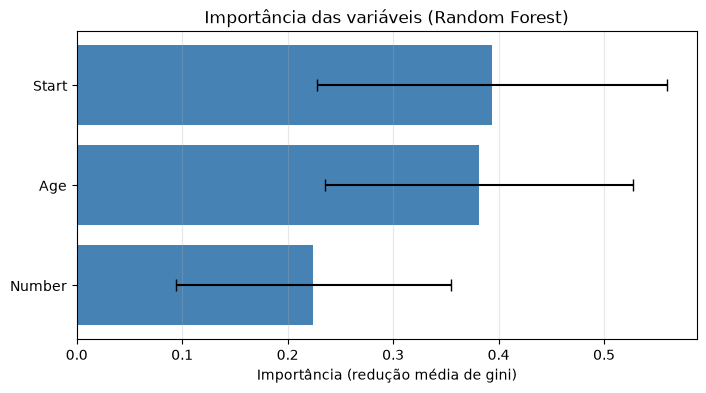

In [10]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced_subsample', random_state=101
)
rf.fit(X_train, y_train)

imp = pd.DataFrame({
    'variavel': X_train.columns,
    'importancia': rf.feature_importances_,
    'desvio_entre_arvores': np.std(
        [arvore.feature_importances_ for arvore in rf.estimators_], axis=0
    ),
}).sort_values('importancia', ascending=False)

print(imp.round(3).to_string(index=False))

imp_plot = imp.sort_values('importancia')
plt.figure(figsize=(8, 4))
plt.barh(imp_plot['variavel'], imp_plot['importancia'],
         xerr=imp_plot['desvio_entre_arvores'], color='steelblue', capsize=4)
plt.xlabel('Importância (redução média de gini)')
plt.title('Importância das variáveis (Random Forest)')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Avaliação final no teste

In [11]:
from sklearn.tree import export_text
from sklearn.metrics import balanced_accuracy_score

final = DecisionTreeClassifier(random_state=101, **grid.best_params_)
final.fit(X_train, y_train)
pred_final = final.predict(X_test)

print("--- Regra aprendida ---")
print(export_text(final, feature_names=list(X_train.columns)))

print("Matriz de confusão (linhas = real, colunas = previsto; ordem: absent, present):")
print(confusion_matrix(y_test, pred_final))

print("\nClassification report:")
print(classification_report(y_test, pred_final))

print("--- Comparações ---")
print(f"Acurácia no teste:            {final.score(X_test, y_test):.3f}")
print(f"Acurácia do modelo bobo:      {(y_test == 'absent').mean():.3f}")
print(f"Balanced accuracy no teste:   {balanced_accuracy_score(y_test, pred_final):.3f}")
print(f"Balanced accuracy na CV:      {grid.best_score_:.3f}")

--- Regra aprendida ---
|--- Start <= 8.50
|   |--- class: present
|--- Start >  8.50
|   |--- class: absent

Matriz de confusão (linhas = real, colunas = previsto; ordem: absent, present):
[[17  3]
 [ 2  3]]

Classification report:
              precision    recall  f1-score   support

      absent       0.89      0.85      0.87        20
     present       0.50      0.60      0.55         5

    accuracy                           0.80        25
   macro avg       0.70      0.72      0.71        25
weighted avg       0.82      0.80      0.81        25

--- Comparações ---
Acurácia no teste:            0.800
Acurácia do modelo bobo:      0.800
Balanced accuracy no teste:   0.725
Balanced accuracy na CV:      0.694


## Visualizando a árvore final

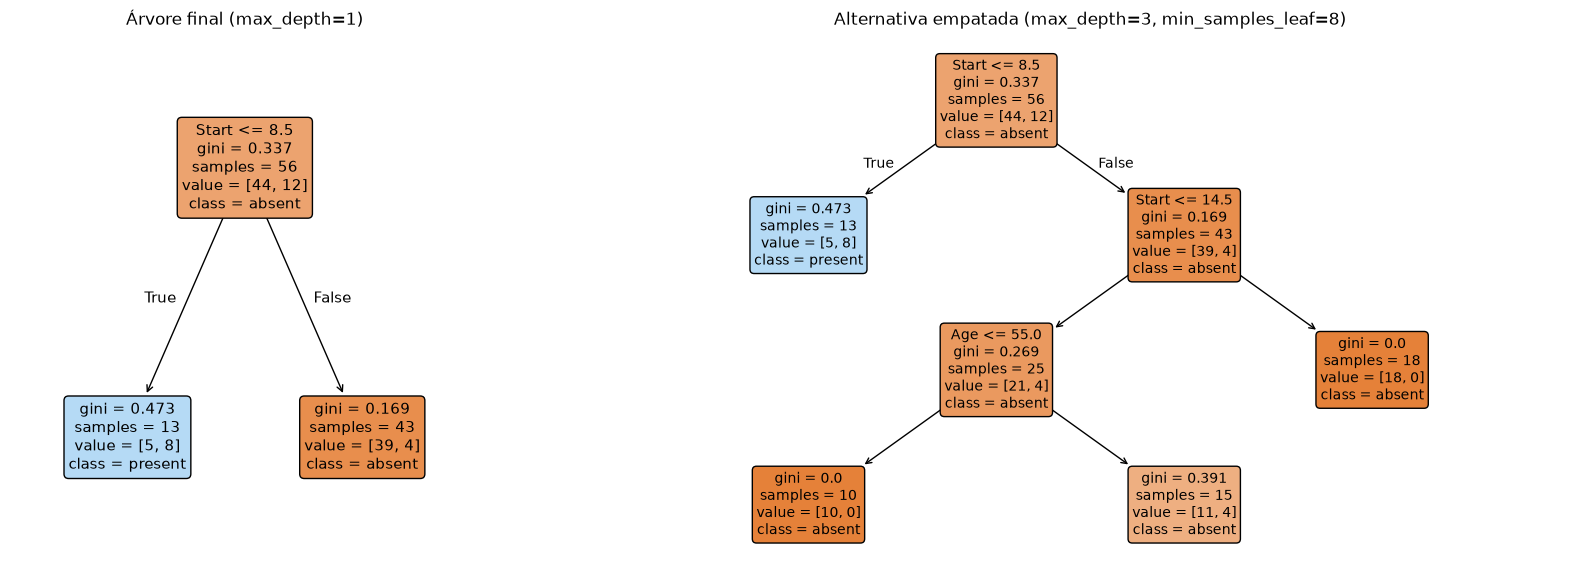

Folhas: final = 2, alternativa = 4


In [12]:
alternativa = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=8, random_state=101
)
alternativa.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 2]})

plot_tree(final, feature_names=X_train.columns, class_names=final.classes_,
          filled=True, rounded=True, fontsize=11, ax=axes[0])
axes[0].set_title('Árvore final (max_depth=1)')

plot_tree(alternativa, feature_names=X_train.columns, class_names=alternativa.classes_,
          filled=True, rounded=True, fontsize=10, ax=axes[1])
axes[1].set_title('Alternativa empatada (max_depth=3, min_samples_leaf=8)')

plt.show()

print(f"Folhas: final = {final.get_n_leaves()}, alternativa = {alternativa.get_n_leaves()}")